In [ ]:
import sys
sys.path.append('../')
import os.path as osp

import torch
from torch.utils.data import DataLoader
import numpy as np
import copy
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt

import qdre
import qdre.Camel.equations as equations

DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
#DEVICE = 'cpu'
print(DEVICE)

cuda:0


/home/mdrnevich/test/QuasiDRE/ToyModels/../utils/__init__.py:4: UserWarning: The recommended fonts to use plothist were not found. You can install them by typing 'install_latin_modern_fonts' in your terminal. If it still does not work, please check the documentation at https://plothist.readthedocs.io/en/latest/usage/font_installation.html
  from . import plotting


# Now create a combined model and optimize the coefficients

In [2]:
SAVE_DIR = "./models"
DATA_DIR = "./data"

In [3]:
batch_size = int(2**8)
subdensity_model_paths = [osp.join(SAVE_DIR, "classifier_subdensity_{}_batch{}.zip".format(i+1, batch_size)) for i in range(4)]

In [ ]:
FINE_TUNE = True

t0 = 25619
t1 = 58
print(t0, t1, -(t0/t1)**2, -t0/t1)

mix_model = qdre.models.MixtureClassifier(subdensity_model_paths, t0=t0, t1=t1, fine_tune=FINE_TUNE).to(DEVICE)
print(mix_model)

25619 58 -195104.9824613555 -441.7068965517241
MixtureClassifier(
  (subclassifiers): ModuleList(
    (0-3): 4 x Classifier(
      (model): Sequential(
        (0): Linear(in_features=2, out_features=32, bias=True)
        (1): ReLU()
        (2): Linear(in_features=32, out_features=32, bias=True)
        (3): ReLU()
        (4): Linear(in_features=32, out_features=1, bias=True)
        (5): Sigmoid()
      )
    )
  )
)


In [5]:
source_file = osp.join(DATA_DIR, "base_distribution_mc_data")
target_file = osp.join(DATA_DIR, "target_distribution_mc_data")

source_positive_file = source_file + "_positives"
source_negative_file = source_file + "_negatives"
target_positive_file = target_file + "_positives"
target_negative_file = target_file + "_negatives"

files = [source_positive_file, source_negative_file, target_positive_file, target_negative_file]

sum_weights = []
for f in files:
    sum_weights.append(np.load(f + "_train.npy")[:,-1].sum())

sum_weights = np.array(sum_weights)
sum_weights

array([1600782., -399218., 1334428., -665572.])

In [6]:
coefficient_init = [sum_weights[0] / sum_weights[:2].sum(), sum_weights[2] / sum_weights[2:].sum()]
coefficient_init

[np.float64(1.3322486359444856), np.float64(1.9950901240326766)]

In [7]:
mix_model.initialize(coefficient_init)
list(mix_model.parameters())

[Parameter containing:
 tensor(1.3322, requires_grad=True),
 Parameter containing:
 tensor(1.9951, requires_grad=True),
 Parameter containing:
 tensor([[ 0.0222,  0.2294],
         [-0.6252, -0.5125],
         [-0.3643,  0.2454],
         [-0.0085,  0.5826],
         [-0.0160,  0.1452],
         [-0.1609, -0.1426],
         [-0.7256, -0.4523],
         [-0.3090,  0.0909],
         [ 0.2491,  0.4755],
         [-0.4400, -0.3366],
         [ 0.2199,  0.6379],
         [-0.1293,  0.4677],
         [-0.0564,  0.0472],
         [ 0.7278, -0.7119],
         [-0.4476, -0.1734],
         [-0.3751,  0.6699],
         [-0.4910, -0.3681],
         [-0.5040, -0.6574],
         [-0.4661,  0.6043],
         [ 0.3921,  0.3837],
         [-0.0037, -0.3635],
         [ 0.1510, -0.6944],
         [-0.5311, -0.3851],
         [ 0.5219,  0.4040],
         [-0.2051, -0.0575],
         [ 0.5019,  0.7222],
         [ 0.2529,  0.0384],
         [ 0.4641, -0.3766],
         [ 0.1412, -0.4382],
         [-0.385

In [ ]:
training_settings_mix = {}

source_mixture_coef = (4, -1)
source_scales = (2.5, 2.3)
target_mixture_coef = (2, -1)
target_scales = (2, 1.2)


MIN_TRAIN_SIZE = int(min([np.load(source_file + "_train.npy").shape[0], np.load(target_file + "_train.npy").shape[0]]))
MIN_VALID_SIZE = int(min([np.load(source_file + "_val.npy").shape[0], np.load(target_file + "_val.npy").shape[0]]))

train_base_dataset = qdre.preprocessing.Dataset(source_file + "_train.npy", 0, stop_event=MIN_TRAIN_SIZE)
valid_base_dataset = qdre.preprocessing.Dataset(source_file + "_val.npy", 0, stop_event=MIN_VALID_SIZE)

train_target_dataset = qdre.preprocessing.Dataset(target_file + "_train.npy", 1, stop_event=MIN_TRAIN_SIZE)
valid_target_dataset = qdre.preprocessing.Dataset(target_file + "_val.npy", 1, stop_event=MIN_VALID_SIZE)

training_settings_mix.update({
    "source_file": source_file,
    "target_file": target_file,
    "source_mixture_coef": source_mixture_coef,
    "source_scales": source_scales,
    "target_mixture_coef": target_mixture_coef,
    "target_scales": target_scales,
    "t0": t0,
    "t1": t1
})

In [9]:
source_weight_norm = train_base_dataset.process(normalize_weights=True)
valid_base_dataset.process(normalize_weights=True)

target_weight_norm = train_target_dataset.process(normalize_weights=True)
valid_target_dataset.process(normalize_weights=True)

tensor(0.3339)

In [ ]:
train_generator_data = qdre.preprocessing.CombinedDataset(train_base_dataset, train_target_dataset)
valid_generator_data = qdre.preprocessing.CombinedDataset(valid_base_dataset, valid_target_dataset)

In [ ]:
X_scaler, train_weight_norm = qdre.preprocessing.get_scaling(train_generator_data)
_, valid_weight_norm = qdre.preprocessing.get_scaling(valid_generator_data)
print(train_weight_norm, valid_weight_norm)

100%|██████████| 1172/1172 [00:04<00:00, 236.27it/s]

tensor(1.0000) tensor(1.0000)


### Save the plain SMM model

In [ ]:
SAVE_SMM = True

if SAVE_SMM:
    SMM_model = qdre.models.MixtureClassifier(subdensity_model_paths, t0=t0, t1=t1, fine_tune=False).to(DEVICE)
    SMM_model.initialize(coefficient_init)
    model_name = "classifier_SMM_batch{}".format(batch_size)
    model_metadata = qdre.train.get_model_metadata(training_settings_mix, SMM_model, X_scaler, train_weight_norm)
    qdre.train.save_model_data(SMM_model, model_metadata, savedir=SAVE_DIR, name=model_name, save_onnx=False, device=DEVICE)

### Now optimize the coefficients

In [32]:
random_seed = 0

torch.manual_seed(random_seed)

train_loader = DataLoader(train_generator_data, batch_size=batch_size, shuffle=True)
valid_loader = DataLoader(valid_generator_data, batch_size=batch_size, shuffle=False)

In [33]:
learning_rate = 1e-4
optimizer = torch.optim.Adam(mix_model.parameters(), lr=learning_rate)

# Get the analytical optimal classifier
s_optimal = equations.optimal_binary_classifier(source_mixture_coef, source_scales, target_mixture_coef, target_scales)

if FINE_TUNE is False:
    model_name = "classifier_SMMc_batch{}".format(batch_size)
else:
    model_name = "classifier_SMMr_batch{}".format(batch_size)

In [ ]:
n_epochs = 1500
stale_epochs = 0
best_valid_loss = 99999
patience = 10
max_num_batches = int(int(1e5) / batch_size)
t = tqdm(range(0, n_epochs))

training_losses = [qdre.train.test(
        mix_model,
        train_loader,
        weight_norm=train_weight_norm,
        loss='pare',
        SMM=True,
        t0=t0,
        t1=t1,
        device=DEVICE,
        max_num_batches=max_num_batches,
        progress_bar=False,
        leave=False
    )[0],]
validation_losses = [qdre.train.test(
        mix_model,
        valid_loader,
        weight_norm=valid_weight_norm,
        loss='pare',
        SMM=True,
        t0=t0,
        t1=t1,
        device=DEVICE,
        progress_bar=False,
        leave=False
    )[0],]

optimal_train_loss = qdre.train.get_optimal_loss(
        s_optimal,
        train_loader,
        weight_norm=train_weight_norm,
        loss='pare',
        t0=t0,
        t1=t1,
        device=DEVICE,
        progress_bar=False
)
optimal_valid_loss = qdre.train.get_optimal_loss(
        s_optimal,
        valid_loader,
        weight_norm=valid_weight_norm,
        loss='pare',
        t0=t0,
        t1=t1,
        device=DEVICE,
        progress_bar=False
)

training_settings_mix.update({
    "optimal_train_loss": optimal_train_loss,
    "optimal_valid_loss": optimal_valid_loss
})

for epoch in t:
    loss = qdre.train.train(
        mix_model,
        optimizer,
        train_loader,
        weight_norm=train_weight_norm,
        max_num_batches=max_num_batches,
        loss='pare',
        SMM=True,
        t0=t0,
        t1=t1,
        device=DEVICE,
        progress_bar=False,
        leave=bool(epoch == n_epochs - 1),
    )
    #loss -= optimal_train_loss
    training_losses.append(loss[0])

    valid_loss = qdre.train.test(
        mix_model,
        valid_loader,
        weight_norm=valid_weight_norm,
        loss='pare',
        SMM=True,
        t0=t0,
        t1=t1,
        device=DEVICE,
        progress_bar=False,
        leave=bool(epoch == n_epochs - 1),
    )
    #valid_loss -= optimal_valid_loss
    validation_losses.append(valid_loss[0])
    print("Epoch: {:02d}, Training Loss:   {:.4f}".format(epoch, loss[1]))
    print("           Validation Loss: {:.4f}".format(valid_loss[1]))

    if valid_loss[1] < best_valid_loss:
        best_valid_loss = valid_loss[1]
        print("New best model with parameters:", mix_model.coefficients)
        training_settings_mix.update({
            "n_epochs": epoch+1,
            "training_losses": training_losses,
            "validation_losses": validation_losses
        })
        model_metadata = qdre.train.get_model_metadata(training_settings_mix, mix_model, X_scaler, train_weight_norm)
        qdre.train.save_model_data(mix_model, model_metadata, savedir=SAVE_DIR, name=model_name, save_onnx=False, device=DEVICE)
        print("New best model saved to: {}.zip".format(osp.join(SAVE_DIR, model_name)))
        stale_epochs = 0
    else:
        print("Stale epoch")
        stale_epochs += 1
    if stale_epochs >= patience:
        print("Early stopping after %i stale epochs" % patience)
        break

  0%|          | 0/1500 [00:00<?, ?it/s]

Epoch: 00, Training Loss:   0.4886
           Validation Loss: 0.4978
New best model with parameters: (1.3281186819076538, 1.9970837831497192)
New best model saved to: ./models/classifier_SMMr_batch256.zip
Epoch: 01, Training Loss:   0.4938
           Validation Loss: 0.4978
New best model with parameters: (1.321901559829712, 1.9945231676101685)
New best model saved to: ./models/classifier_SMMr_batch256.zip
Epoch: 02, Training Loss:   0.4863
           Validation Loss: 0.4978
New best model with parameters: (1.3155896663665771, 1.9957715272903442)
New best model saved to: ./models/classifier_SMMr_batch256.zip
Epoch: 03, Training Loss:   0.4980
           Validation Loss: 0.4978
Stale epoch
Epoch: 04, Training Loss:   0.4857
           Validation Loss: 0.4978
Stale epoch
Epoch: 05, Training Loss:   0.5099
           Validation Loss: 0.4978
Stale epoch
Epoch: 06, Training Loss:   0.4957
           Validation Loss: 0.4978
Stale epoch
Epoch: 07, Training Loss:   0.4920
           Validatio

## Look at the loss curves

Text(0, 0.5, 'BCE Loss')

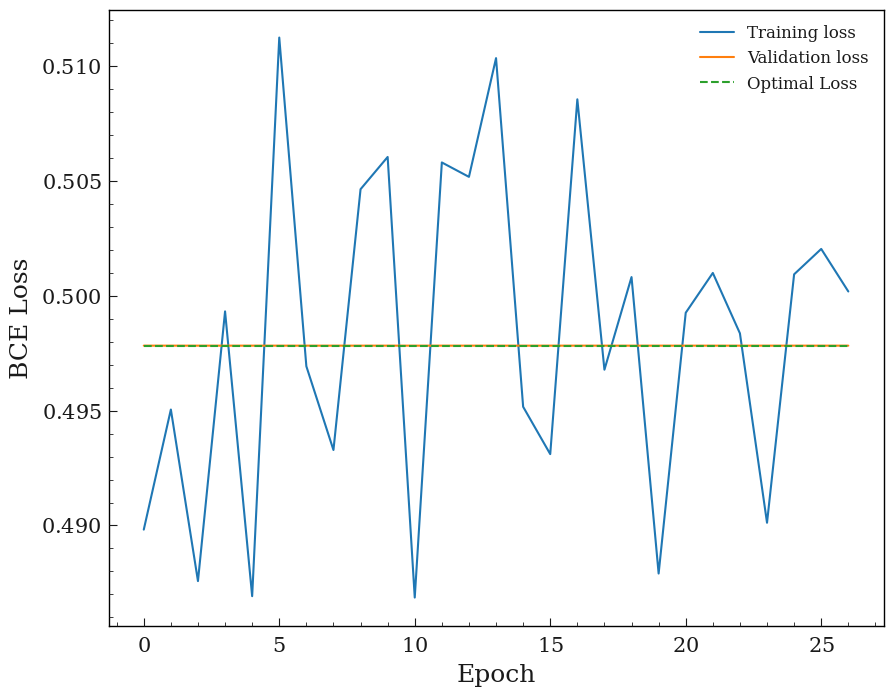

In [35]:
fig,ax = plt.subplots()
fig.set_size_inches(10, 8)

starting_epoch = 1
training_loss_per_epoch = np.array(training_losses[starting_epoch:]).mean(axis=1)
training_std_per_epoch = np.array(training_losses[starting_epoch:]).std(axis=1)

validation_loss_per_epoch = np.array(validation_losses[starting_epoch:]).mean(axis=1)
validation_std_per_epoch = np.array(validation_losses[starting_epoch:]).std(axis=1)

training_lower_bar = training_loss_per_epoch - training_std_per_epoch
training_upper_bar = training_loss_per_epoch + training_std_per_epoch

validation_lower_bar = validation_loss_per_epoch - validation_std_per_epoch
validation_upper_bar = validation_loss_per_epoch + validation_std_per_epoch


t1 = np.arange(len(training_loss_per_epoch))
t2 = np.arange(len(validation_loss_per_epoch))
ax.plot(t1, training_loss_per_epoch, '-', label="Training loss", c='tab:blue')
#ax.fill_between(t1, training_lower_bar, training_upper_bar, color='tab:blue', alpha=0.30)

ax.plot(t2, validation_loss_per_epoch, '-', label="Validation loss", c='tab:orange')
#ax.fill_between(t2, validation_lower_bar, validation_upper_bar, color='tab:orange', alpha=0.30)

ax.plot([0, max([t1.max(), t2.max()])], [training_settings_mix["optimal_valid_loss"]]*2, '--', color='tab:green', label="Optimal Loss")

#ax.set_xscale('log')
ax.legend()
ax.set_xlabel("Epoch")
ax.set_ylabel("BCE Loss")